# Notebook 11 - Initialisation MCARMA(2,1)

This notebook keeps only the direct initialization workflow used before the exact QMLE calibration:

1. align the deseasonalized temperature and price residuals;
2. fit a VAR(2) only to obtain stable continuous-time AR starting matrices;
3. set `B0` from the lower Cholesky factor of the VAR innovation covariance;
4. estimate a constrained lower-triangular `B1` by matching autocovariances.

The MCARMA convention is `P(z) = I z^2 + A1 z + A2`, `Q(z) = B0 z + B1`, with
`beta = [B0; B1 - A1 @ B0]`.

In [90]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.linalg import expm, solve, solve_discrete_lyapunov
from scipy.optimize import least_squares
from statsmodels.tsa.api import VAR

h = 1.0
r_min = 0.01
K_MOMENTS = 10
TOL = 1e-8

I2 = np.eye(2)
Z2 = np.zeros((2, 2))
C = np.hstack([I2, Z2])
Sigma_L = np.eye(2)

## Data

The ordering is fixed throughout the notebook: `Y = (temperature, price)'`.

In [91]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "deseasonalised" / "temp_resid.csv").exists()
)

temp_resid = pd.read_csv(
    PROJECT_ROOT / "data" / "deseasonalised" / "temp_resid.csv",
    index_col=0,
    parse_dates=True,
)
price_resid = pd.read_csv(
    PROJECT_ROOT / "data" / "deseasonalised" / "price_resid.csv",
    index_col=0,
    parse_dates=True,
)

temp_res = temp_resid["temp_deseasoned"].rename("temp").sort_index()
price_res = price_resid["price_deseasoned"].rename("price").sort_index()

Y = pd.concat([temp_res, price_res], axis=1, join="inner").dropna()
Y_np = Y.to_numpy(dtype=float)
time_index = Y.index.copy()

print(
    f"Aligned sample: n={len(Y)}, "
    f"range={Y.index.min()} -> {Y.index.max()}"
)

Aligned sample: n=26281, range=2023-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00


## AR Start From VAR(2)

The VAR(2) is only an initialization device. The structural restriction
`A1[0, 1] = A2[0, 1] = 0` removes price-to-temperature feedback.

In [92]:
var_res = VAR(Y).fit(2, trend="n")

Phi1 = np.asarray(var_res.coefs[0], dtype=float)
Phi2 = np.asarray(var_res.coefs[1], dtype=float)
Sigma_u = np.asarray(var_res.sigma_u, dtype=float)

A1_init = (2.0 * I2 - Phi1) / h
A2_init = (I2 - Phi1 - Phi2) / (h ** 2)

A1_init[0, 1] = 0.0
A2_init[0, 1] = 0.0

A_comp_init = np.block([
    [Z2, I2],
    [-A2_init, -A1_init],
])

A_eigenvalues = np.linalg.eigvals(A_comp_init)
max_real_A = float(np.max(np.real(A_eigenvalues)))

if max_real_A >= -TOL:
    raise ValueError(
        f"Initial AR matrix is not stable: max Re(eig(A_comp))={max_real_A:.6g}"
    )

print(f"AR start is stable: max Re(eig(A_comp))={max_real_A:.6g}")

AR start is stable: max Re(eig(A_comp))=-0.0262979


## Direct MA Start

We keep the robust version only:

- `B0` is the lower Cholesky factor of `Sigma_u / h`;
- `B1` is lower triangular;
- the diagonal ratios satisfy `r_T, r_P >= r_min`, so the diagonal MA zeros are `-r_T` and `-r_P`.

In [93]:
def make_spd(matrix, eigenvalue_floor=1e-12):
    """Return a symmetric positive definite approximation of a matrix."""
    symmetric = 0.5 * (np.asarray(matrix, dtype=float) + np.asarray(matrix, dtype=float).T)
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric)
    eigenvalues = np.maximum(eigenvalues, eigenvalue_floor)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T


def sample_autocovariances(values, max_lag, demean=True):
    """Compute sample autocovariances Gamma_k = Cov(Y_{t+k}, Y_t)."""
    array = np.asarray(values, dtype=float)
    if demean:
        array = array - array.mean(axis=0, keepdims=True)

    gammas = []
    for lag in range(max_lag + 1):
        lead = array[lag:] if lag else array
        lagged = array[:-lag] if lag else array
        gammas.append((lead.T @ lagged) / lead.shape[0])
    return gammas


def build_beta(A1, B0, B1):
    """Build beta for the convention Q(z) = B0 z + B1."""
    return np.vstack([B0, B1 - A1 @ B0])


def discretized_noise_covariance(A_comp, beta, Sigma_L, step):
    """Compute the exact discrete noise covariance with the Van Loan method."""
    n_states = A_comp.shape[0]
    diffusion = beta @ Sigma_L @ beta.T
    block = np.block([
        [A_comp, diffusion],
        [np.zeros((n_states, n_states)), -A_comp.T],
    ])
    exponential = expm(block * step)
    upper_right = exponential[:n_states, n_states:]
    lower_right = exponential[n_states:, n_states:]
    Qh = solve(lower_right.T, upper_right.T, assume_a="gen").T
    return 0.5 * (Qh + Qh.T)


def make_B1_from_theta(theta, B0, r_min):
    """Build lower-triangular B1 with a positive MA invertibility margin."""
    r_T = r_min + np.exp(theta[0])
    b1_PT = theta[1]
    r_P = r_min + np.exp(theta[2])
    return np.array([
        [r_T * B0[0, 0], 0.0],
        [b1_PT, r_P * B0[1, 1]],
    ])


def theoretical_autocovariances(A_comp, A1, B0, B1, Sigma_L, step, max_lag):
    """Compute Gamma_k = C F^k Vx C' for k = 0, ..., max_lag."""
    beta = build_beta(A1, B0, B1)
    Fh = expm(A_comp * step)
    Qh = discretized_noise_covariance(A_comp, beta, Sigma_L, step)
    Vx = solve_discrete_lyapunov(Fh, Qh)
    Vx = 0.5 * (Vx + Vx.T)

    gammas = []
    F_power = np.eye(A_comp.shape[0])
    for _ in range(max_lag + 1):
        gammas.append(C @ F_power @ Vx @ C.T)
        F_power = F_power @ Fh
    return gammas, Qh, Vx


def moment_residuals(theta, A_comp, A1, B0, Sigma_L, step, gamma_hat, r_min):
    """Autocovariance matching residuals used only for initialization."""
    B1 = make_B1_from_theta(theta, B0, r_min)
    gamma_model, _, _ = theoretical_autocovariances(
        A_comp=A_comp,
        A1=A1,
        B0=B0,
        B1=B1,
        Sigma_L=Sigma_L,
        step=step,
        max_lag=len(gamma_hat) - 1,
    )
    scale = max(np.linalg.norm(gamma_hat[0], ord="fro"), 1e-12)
    return np.concatenate([
        ((gamma_model[lag] - gamma_hat[lag]) / scale).reshape(-1)
        for lag in range(len(gamma_hat))
    ])


def controllability_rank(A_comp, beta, tol=1e-9):
    """Rank of [beta, A beta, A^2 beta, A^3 beta]."""
    blocks = []
    current = beta.copy()
    for _ in range(A_comp.shape[0]):
        blocks.append(current)
        current = A_comp @ current
    return np.linalg.matrix_rank(np.hstack(blocks), tol=tol)


def initialization_checks(A_comp, A1, A2, B0, B1, beta, Qh, Vx, r_min, tol):
    """Collect concise diagnostics for the initialization point."""
    ma_zeros = np.linalg.eigvals(-solve(B0, B1, assume_a="gen"))
    return {
        "A1_upper_right_zero": bool(abs(A1[0, 1]) < tol),
        "A2_upper_right_zero": bool(abs(A2[0, 1]) < tol),
        "B0_upper_right_zero": bool(abs(B0[0, 1]) < tol),
        "B1_upper_right_zero": bool(abs(B1[0, 1]) < tol),
        "B0_positive_diagonal": bool(np.all(np.diag(B0) > tol)),
        "B1_positive_diagonal": bool(np.all(np.diag(B1) > tol)),
        "max_real_A_eigenvalue": float(np.max(np.real(np.linalg.eigvals(A_comp)))),
        "ma_zeros": ma_zeros,
        "MA_margin_ok": bool(np.max(np.real(ma_zeros)) <= -r_min + tol),
        "Qh_min_eigenvalue": float(np.min(np.linalg.eigvalsh(Qh))),
        "Vx_min_eigenvalue": float(np.min(np.linalg.eigvalsh(Vx))),
        "controllability_rank": int(controllability_rank(A_comp, beta, tol=tol)),
    }

In [94]:
gamma_hat = sample_autocovariances(Y_np, max_lag=K_MOMENTS, demean=True)

Sigma_u_spd = make_spd(Sigma_u)
B0_init = np.linalg.cholesky(Sigma_u_spd / h)
B0_init[0, 1] = 0.0

theta_start = np.array([
    np.log(max(1.0 - r_min, 1e-8)),
    B0_init[1, 0],
    np.log(max(1.0 - r_min, 1e-8)),
])

ls_res = least_squares(
    fun=moment_residuals,
    x0=theta_start,
    args=(A_comp_init, A1_init, B0_init, Sigma_L, h, gamma_hat, r_min),
    method="trf",
    max_nfev=5000,
    xtol=1e-10,
    ftol=1e-10,
    gtol=1e-10,
)

B1_init = make_B1_from_theta(ls_res.x, B0_init, r_min)
beta_init = build_beta(A1_init, B0_init, B1_init)
Fh_init = expm(A_comp_init * h)
Qh_init = discretized_noise_covariance(A_comp_init, beta_init, Sigma_L, h)
Vx_init = solve_discrete_lyapunov(Fh_init, Qh_init)
Vx_init = 0.5 * (Vx_init + Vx_init.T)

checks = initialization_checks(
    A_comp=A_comp_init,
    A1=A1_init,
    A2=A2_init,
    B0=B0_init,
    B1=B1_init,
    beta=beta_init,
    Qh=Qh_init,
    Vx=Vx_init,
    r_min=r_min,
    tol=TOL,
)

mcarma_initialization = {
    "A1_init": A1_init,
    "A2_init": A2_init,
    "B0_init": B0_init,
    "B1_init": B1_init,
    "beta_init": beta_init,
    "A_comp_init": A_comp_init,
    "Sigma_u": Sigma_u,
    "h": h,
    "checks": checks,
    "least_squares_result": ls_res,
}

pd.Series({
    "least_squares_success": bool(ls_res.success),
    "least_squares_cost": ls_res.cost,
    "max_real_A_eigenvalue": checks["max_real_A_eigenvalue"],
    "MA_margin_ok": checks["MA_margin_ok"],
    "Qh_min_eigenvalue": checks["Qh_min_eigenvalue"],
    "Vx_min_eigenvalue": checks["Vx_min_eigenvalue"],
    "controllability_rank": checks["controllability_rank"],
})

least_squares_success        True
least_squares_cost       0.000185
max_real_A_eigenvalue   -0.026298
MA_margin_ok                 True
Qh_min_eigenvalue             0.0
Vx_min_eigenvalue        0.000007
controllability_rank            4
dtype: object

The dictionary `mcarma_initialization` contains the matrices to pass to the QMLE calibration module.

In [95]:
{key: mcarma_initialization[key] for key in ["A1_init", "A2_init", "B0_init", "B1_init"]}

{'A1_init': array([[ 7.07663406e-01,  0.00000000e+00],
        [-1.51794886e-04,  8.53694714e-01]]),
 'A2_init': array([[ 1.79184720e-02,  0.00000000e+00],
        [-4.24313681e-05,  9.27589983e-02]]),
 'B0_init': array([[ 5.84941733e-01,  0.00000000e+00],
        [-3.15215018e-04,  1.23989368e-02]]),
 'B1_init': array([[ 0.59537432,  0.        ],
        [-0.00187431,  0.01311701]])}

## Direct Exact MLE for A1, A2, and B1

The calibration code lives in `mcarma_calibration.py`. In this notebook we now use the direct mode
`A1_A2_B1`: `B0` is fixed from the Cholesky initialization, while the optimizer moves the lower-triangular
AR matrices `A1`, `A2`, and the constrained lower-triangular `B1`.

In [96]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mcarma_calibration import (
    build_A_comp as mcarma_build_A_comp,
    build_C as mcarma_build_C,
    build_beta as mcarma_build_beta,
    calibrate_mcarma21,
    diagnostics as mcarma_diagnostics,
    discretize_exact,
    stationary_state_covariance,
)

## Initial MCARMA Diagnostics

These checks are evaluated before optimization and use the exact MCARMA convention
`Q(z) = B0 z + B1`.

In [97]:
A_comp_start = mcarma_build_A_comp(A1_init, A2_init)
C_mcarma = mcarma_build_C()
beta_start = mcarma_build_beta(A1_init, B0_init, B1_init)
F_start, Q_start = discretize_exact(A_comp_start, beta_start, h=h, Sigma_L=Sigma_L)
Vx_start = stationary_state_covariance(F_start, Q_start)

initial_mcarma_diagnostics = mcarma_diagnostics(
    A1=A1_init,
    A2=A2_init,
    B0=B0_init,
    B1=B1_init,
    beta=beta_start,
    A_comp=A_comp_start,
    F_h=F_start,
    Q_h=Q_start,
    Vx=Vx_start,
    r_min=r_min,
    ar_margin=1e-6,
    psd_tol=1e-10,
)

pd.Series({
    "AR_stable": initial_mcarma_diagnostics["AR_stable"],
    "MA_invertible": initial_mcarma_diagnostics["MA_invertible"],
    "Qh_positive_semidefinite": initial_mcarma_diagnostics["Qh_positive_semidefinite"],
    "Vx_positive_semidefinite": initial_mcarma_diagnostics["Vx_positive_semidefinite"],
    "controllability_rank": initial_mcarma_diagnostics["controllability_rank"],
    "transfer_function_test_max_error": initial_mcarma_diagnostics["transfer_function_test_max_error"],
})

AR_stable                           True
MA_invertible                       True
Qh_positive_semidefinite            True
Vx_positive_semidefinite            True
controllability_rank                   4
transfer_function_test_max_error     0.0
dtype: object

## Run Direct MLE

`DIRECT_MLE_MAXITER` is moderate by default. Directly optimizing `A1`, `A2`, and `B1`
means 9 free parameters, but the Kalman likelihood uses Numba acceleration when available.
Increase this value for the actual calibration run.

In [98]:
DIRECT_MLE_MAXITER = 1000

result_direct = calibrate_mcarma21(
    Y_np,
    A1_init=A1_init,
    A2_init=A2_init,
    Sigma_u=Sigma_u,
    B0_init=B0_init,
    B1_init=B1_init,
    h=h,
    r_min=r_min,
    mode="A1_A2_B1",
    demean=True,
    maxiter=DIRECT_MLE_MAXITER,
    verbose=True,
)

pd.Series({
    "success": result_direct["success"],
    "message": result_direct["message"],
    "n_iter": result_direct["n_iter"],
    "final_negative_loglik": result_direct["final_negative_loglik"],
    "average_loglik_per_observation": result_direct["average_loglik_per_observation"],
    "AR_stable": result_direct["diagnostics"]["AR_stable"],
    "MA_invertible": result_direct["diagnostics"]["MA_invertible"],
    "transfer_function_test_max_error": result_direct["diagnostics"]["transfer_function_test_max_error"],
})

Initial negative log-likelihood (A1_A2_B1): -53778.345817
Final negative log-likelihood (A1_A2_B1): -53950.033842
Optimizer success (A1_A2_B1): True; CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


success                                                                          True
message                             CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
n_iter                                                                            199
final_negative_loglik                                                   -53950.033842
average_loglik_per_observation                                               2.052815
AR_stable                                                                        True
MA_invertible                                                                    True
transfer_function_test_max_error                                                  0.0
dtype: object

In [99]:
final_mcarma_result = result_direct

{
    "A1": final_mcarma_result["A1"],
    "A2": final_mcarma_result["A2"],
    "B0": final_mcarma_result["B0"],
    "B1": final_mcarma_result["B1"],
    "diagnostics": final_mcarma_result["diagnostics"],
}

{'A1': array([[ 0.41101903,  0.        ],
        [-0.00368888,  1.06056117]]),
 'A2': array([[ 0.01246894,  0.        ],
        [-0.00012565,  0.11129977]]),
 'B0': array([[ 5.84941733e-01,  0.00000000e+00],
        [-3.15215018e-04,  1.23989368e-02]]),
 'B1': array([[ 0.37902798,  0.        ],
        [-0.00307197,  0.01580524]]),
 'diagnostics': {'B0_shape_ok': True,
  'B1_shape_ok': True,
  'beta_shape_ok': True,
  'no_price_to_temperature_AR': True,
  'no_price_to_temperature_MA': True,
  'B0_positive_diagonal': True,
  'B1_positive_diagonal': True,
  'det_B0': 0.007252655588683588,
  'B0_invertible': True,
  'ma_zeros': array([-1.27472532, -0.64797562]),
  'MA_invertible': True,
  'A_eigenvalues': array([-0.94246711, -0.37803551, -0.03298352, -0.11809406]),
  'AR_stable': True,
  'Qh_eigenvalues': array([6.12216668e-07, 1.74809340e-04, 4.20201833e-04, 4.28343310e-01]),
  'Qh_positive_semidefinite': True,
  'Vx_eigenvalues': array([6.36519253e-06, 1.13639986e-03, 2.65297739e-02, 

## Continue With Full MLE

This stage starts from `result_direct` and releases `B0` as well. The first MLE result is kept unchanged;
the new result is stored as `result_full_from_direct`.

In [100]:
RUN_FULL_FROM_DIRECT = True
FULL_MLE_MAXITER = 5000
FULL_MLE_OPTIMIZER_OPTIONS = {
    "maxfun": 20000,
    "ftol": 1e-9,
    "gtol": 1e-5,
}

if RUN_FULL_FROM_DIRECT:
    result_full_from_direct = calibrate_mcarma21(
        Y_np,
        A1_init=result_direct["A1"],
        A2_init=result_direct["A2"],
        B0_init=result_direct["B0"],
        B1_init=result_direct["B1"],
        h=h,
        r_min=r_min,
        mode="full",
        demean=True,
        maxiter=FULL_MLE_MAXITER,
        verbose=True,
    )
else:
    result_full_from_direct = None

result_full_from_direct is not None

Initial negative log-likelihood (full): -53950.033842
Final negative log-likelihood (full): -54988.670421
Optimizer success (full): False; STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT


True

## Likelihood Comparison

The table compares the initial point, the direct MLE with fixed `B0`, and the optional full MLE with free `B0`.

In [101]:
initial_loglik = calibrate_mcarma21(
    Y_np,
    A1_init=A1_init,
    A2_init=A2_init,
    B0_init=B0_init,
    B1_init=B1_init,
    h=h,
    r_min=r_min,
    mode="A1_A2_B1",
    demean=True,
    maxiter=0,
    optimizer_options={"maxfun": 1},
    verbose=False,
)["final_loglik"]

calibration_comparison_rows = [
    {
        "stage": "initial",
        "success": True,
        "message": "initial parameters",
        "n_iter": 0,
        "final_loglik": -mcarma_initialization["checks"].get("negative_loglik", np.nan),
        "final_negative_loglik": np.nan,
        "average_loglik_per_observation": np.nan,
        "AR_stable": initial_mcarma_diagnostics["AR_stable"],
        "MA_invertible": initial_mcarma_diagnostics["MA_invertible"],
        "transfer_error": initial_mcarma_diagnostics["transfer_function_test_max_error"],
    },
    {
        "stage": "A1_A2_B1_fixed_B0",
        "success": result_direct["success"],
        "message": result_direct["message"],
        "n_iter": result_direct["n_iter"],
        "final_loglik": result_direct["final_loglik"],
        "final_negative_loglik": result_direct["final_negative_loglik"],
        "average_loglik_per_observation": result_direct["average_loglik_per_observation"],
        "AR_stable": result_direct["diagnostics"]["AR_stable"],
        "MA_invertible": result_direct["diagnostics"]["MA_invertible"],
        "transfer_error": result_direct["diagnostics"]["transfer_function_test_max_error"],
    },
]

if result_full_from_direct is not None:
    calibration_comparison_rows.append(
        {
            "stage": "full_free_B0",
            "success": result_full_from_direct["success"],
            "message": result_full_from_direct["message"],
            "n_iter": result_full_from_direct["n_iter"],
            "final_loglik": result_full_from_direct["final_loglik"],
            "final_negative_loglik": result_full_from_direct["final_negative_loglik"],
            "average_loglik_per_observation": result_full_from_direct["average_loglik_per_observation"],
            "AR_stable": result_full_from_direct["diagnostics"]["AR_stable"],
            "MA_invertible": result_full_from_direct["diagnostics"]["MA_invertible"],
            "transfer_error": result_full_from_direct["diagnostics"]["transfer_function_test_max_error"],
        }
    )

calibration_comparison = pd.DataFrame(calibration_comparison_rows)
calibration_comparison

,stage,success,message,n_iter,final_loglik,final_negative_loglik,average_loglik_per_observation,AR_stable,MA_invertible,transfer_error
0,initial,True,initial parameters,0,NaN,NaN,NaN,True,True,2.938904e-16
1,A1_A2_B1_fixed_B0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,199,53950.033842,-53950.033842,2.052815,True,True,2.072849e-16
2,full_free_B0,False,"STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT",1023,54988.670421,-54988.670421,2.092336,True,True,2.876503e-16


In [102]:
final_mcarma_result = (
    result_full_from_direct
    if result_full_from_direct is not None
    else result_direct
)

{
    "A1": final_mcarma_result["A1"],
    "A2": final_mcarma_result["A2"],
    "B0": final_mcarma_result["B0"],
    "B1": final_mcarma_result["B1"],
    "diagnostics": final_mcarma_result["diagnostics"],
}

{'A1': array([[ 7.77632624e-01,  0.00000000e+00],
        [-1.58607741e-03,  2.52603392e+00]]),
 'A2': array([[ 2.27493251e-02,  0.00000000e+00],
        [-1.76832456e-04,  3.02810565e-01]]),
 'B0': array([[ 4.35099956e-01,  0.00000000e+00],
        [-1.77496616e-05,  1.99762447e-03]]),
 'B1': array([[ 0.70665524,  0.        ],
        [-0.00212427,  0.04147153]]),
 'diagnostics': {'B0_shape_ok': True,
  'B1_shape_ok': True,
  'beta_shape_ok': True,
  'no_price_to_temperature_AR': True,
  'no_price_to_temperature_MA': True,
  'B0_positive_diagonal': True,
  'B1_positive_diagonal': True,
  'det_B0': 0.0008691663173450461,
  'B0_invertible': True,
  'ma_zeros': array([-20.76042196,  -1.6241216 ]),
  'MA_invertible': True,
  'A_eigenvalues': array([-2.39985524, -0.74718595, -0.03044667, -0.12617868]),
  'AR_stable': True,
  'Qh_eigenvalues': array([7.13446809e-05, 3.09665125e-04, 6.97435800e-03, 3.98867388e-01]),
  'Qh_positive_semidefinite': True,
  'Vx_eigenvalues': array([2.63093252e-0

## One-Step Ahead MCARMA Fit

This section evaluates the in-sample one-step-ahead fit of the calibrated bivariate MCARMA model. It uses `final_mcarma_result`, so the direct MLE and the optional full MLE results above remain unchanged.


In [103]:
import matplotlib.pyplot as plt
from scipy.linalg import cholesky, solve_triangular
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from mcarma_calibration import kalman_loglik


def _cholesky_with_progressive_jitter(covariance, jitter=1e-10, max_attempts=9):
    """Return a lower Cholesky factor, adding jitter only for numerical stability."""
    covariance = 0.5 * (np.asarray(covariance, dtype=float) + np.asarray(covariance, dtype=float).T)
    identity = np.eye(covariance.shape[0])
    base_jitter = max(float(jitter), 1e-14)

    for attempt in range(max_attempts):
        current_jitter = 0.0 if attempt == 0 else base_jitter * (10.0 ** (attempt - 1))
        try:
            return cholesky(
                covariance + current_jitter * identity,
                lower=True,
                check_finite=False,
            )
        except np.linalg.LinAlgError:
            continue

    raise np.linalg.LinAlgError("Innovation covariance Cholesky failed after progressive jitter.")


def build_mcarma_one_step_fit(Y_values, fitted_result, index, jitter=1e-10):
    """Compute one-step-ahead MCARMA predictions and innovation diagnostics."""
    observed = np.asarray(Y_values, dtype=float)
    if observed.ndim != 2 or observed.shape[1] != 2:
        raise ValueError(f"Y_values must have shape (n_obs, 2), got {observed.shape}.")

    mean_used = np.asarray(fitted_result.get("mean_used", np.zeros(2)), dtype=float)
    centered_observed = observed - mean_used.reshape(1, 2)

    loglik, innovations, innovation_covariances = kalman_loglik(
        centered_observed,
        F_h=fitted_result["F_h"],
        Q_h=fitted_result["Q_h"],
        C=fitted_result["C"],
        Vx=fitted_result["Vx"],
        jitter=jitter,
        return_details=True,
        covariance_convergence_tol=None,
    )

    predicted_centered = centered_observed - innovations
    predicted = predicted_centered + mean_used.reshape(1, 2)

    variances = np.diagonal(innovation_covariances, axis1=1, axis2=2)
    componentwise_std_innovations = innovations / np.sqrt(
        np.maximum(variances, np.finfo(float).tiny)
    )

    whitened_innovations = np.empty_like(innovations)
    for row_index, (innovation, covariance) in enumerate(zip(innovations, innovation_covariances)):
        chol_factor = _cholesky_with_progressive_jitter(covariance, jitter=jitter)
        whitened_innovations[row_index] = solve_triangular(
            chol_factor,
            innovation,
            lower=True,
            check_finite=False,
        )

    fit_index = pd.DatetimeIndex(pd.to_datetime(index, utc=True))
    fit_frame = pd.DataFrame(
        {
            "temp_observed": observed[:, 0],
            "temp_predicted": predicted[:, 0],
            "temp_innovation": innovations[:, 0],
            "temp_component_std_innovation": componentwise_std_innovations[:, 0],
            "temp_whitened_innovation": whitened_innovations[:, 0],
            "price_observed": observed[:, 1],
            "price_predicted": predicted[:, 1],
            "price_innovation": innovations[:, 1],
            "price_component_std_innovation": componentwise_std_innovations[:, 1],
            "price_whitened_innovation": whitened_innovations[:, 1],
        },
        index=fit_index,
    )

    metrics = pd.DataFrame(
        {
            "RMSE": np.sqrt(np.mean(innovations**2, axis=0)),
            "MAE": np.mean(np.abs(innovations), axis=0),
            "innovation_mean": np.mean(innovations, axis=0),
            "innovation_std": np.std(innovations, axis=0, ddof=1),
            "component_std_innovation_std": np.std(componentwise_std_innovations, axis=0, ddof=1),
            "whitened_innovation_std": np.std(whitened_innovations, axis=0, ddof=1),
        },
        index=["temperature", "price"],
    )

    summary = pd.Series(
        {
            "one_step_loglik": float(loglik),
            "stored_final_loglik": float(fitted_result["final_loglik"]),
            "loglik_difference": float(loglik - fitted_result["final_loglik"]),
            "average_loglik_per_observation": float(loglik / len(observed)),
            "n_obs": int(len(observed)),
        }
    )

    return {
        "frame": fit_frame,
        "metrics": metrics,
        "summary": summary,
        "innovations": innovations,
        "componentwise_std_innovations": componentwise_std_innovations,
        "whitened_innovations": whitened_innovations,
        "innovation_covariances": innovation_covariances,
        "predicted": predicted,
        "predicted_centered": predicted_centered,
        "loglik": float(loglik),
    }


In [104]:
mcarma_one_step_fit = build_mcarma_one_step_fit(
    Y_values=Y_np,
    fitted_result=final_mcarma_result,
    index=time_index,
    jitter=1e-10,
)

mcarma_fit_frame = mcarma_one_step_fit["frame"]
mcarma_fit_metrics = mcarma_one_step_fit["metrics"]
mcarma_fit_summary = mcarma_one_step_fit["summary"]

ljungbox_lags = [lag for lag in [24, 48, 72] if lag < len(mcarma_fit_frame)]
ljungbox_rows = []
if ljungbox_lags:
    for column_name, label in [
        ("temp_whitened_innovation", "temperature whitened"),
        ("price_whitened_innovation", "price whitened"),
    ]:
        lb = acorr_ljungbox(
            mcarma_fit_frame[column_name].to_numpy(),
            lags=ljungbox_lags,
            return_df=True,
        )
        lb.insert(0, "component", label)
        ljungbox_rows.append(lb.reset_index(names="lag"))

mcarma_ljungbox = pd.concat(ljungbox_rows, ignore_index=True) if ljungbox_rows else pd.DataFrame()

display(mcarma_fit_summary)
display(mcarma_fit_metrics)
display(mcarma_ljungbox)


one_step_loglik                   5.498867e+04
stored_final_loglik               5.498867e+04
loglik_difference                 7.203198e-10
average_loglik_per_observation    2.092336e+00
n_obs                             2.628100e+04
dtype: float64

,RMSE,MAE,innovation_mean,innovation_std,component_std_innovation_std,whitened_innovation_std
temperature,0.591476,0.400774,8.824067e-05,0.591487,0.999426,0.999426
price,0.012344,0.007382,1.470875e-07,0.012344,0.999033,0.999033


,lag,component,lb_stat,lb_pvalue
0,24,temperature whitened,1094.665477,6.680709e-216
1,48,temperature whitened,1909.570027,0.000000e+00
2,72,temperature whitened,2461.425344,0.000000e+00
3,24,price whitened,1871.623784,0.000000e+00
4,48,price whitened,2280.420102,0.000000e+00
5,72,price whitened,2477.496053,0.000000e+00


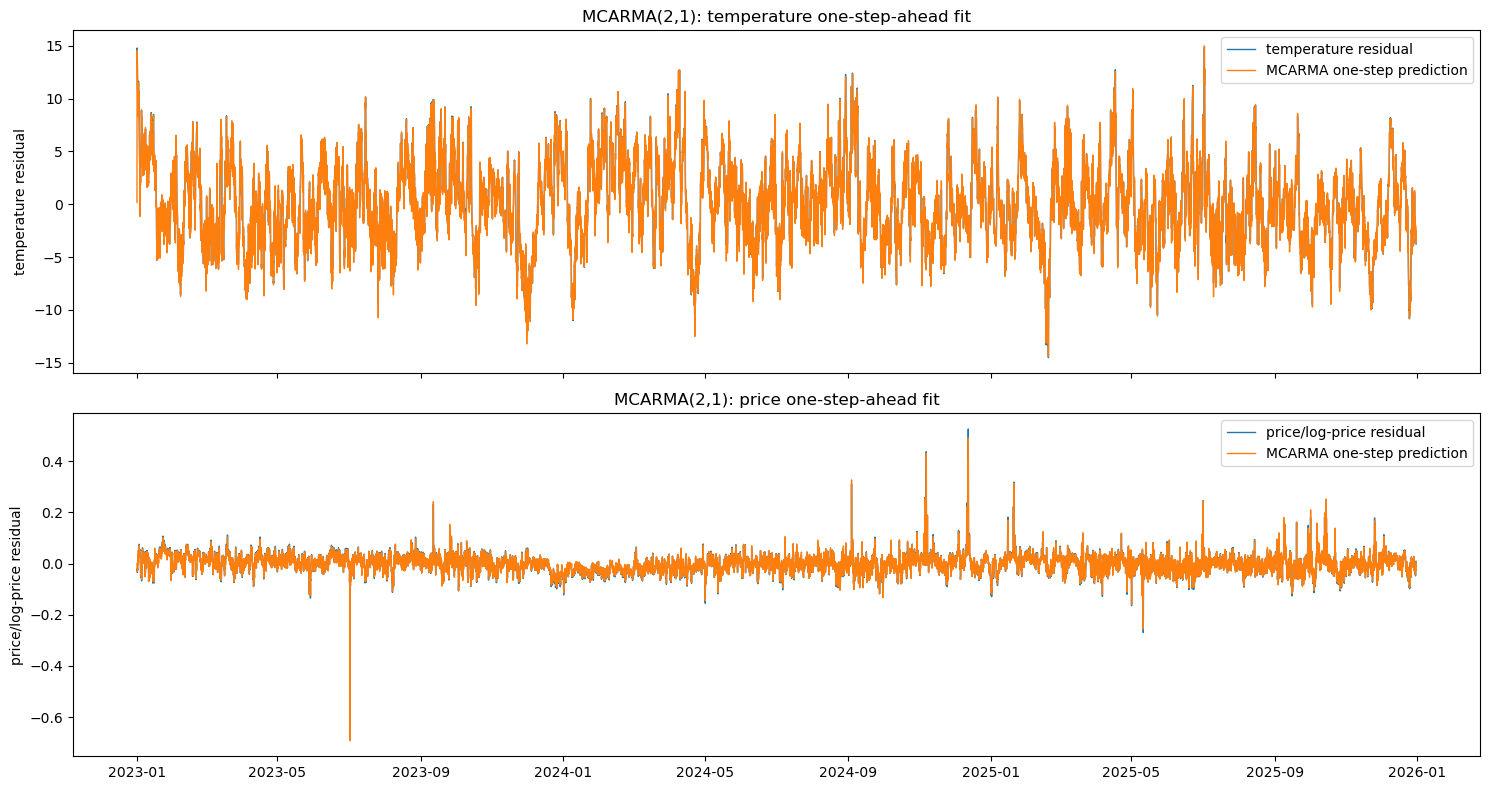

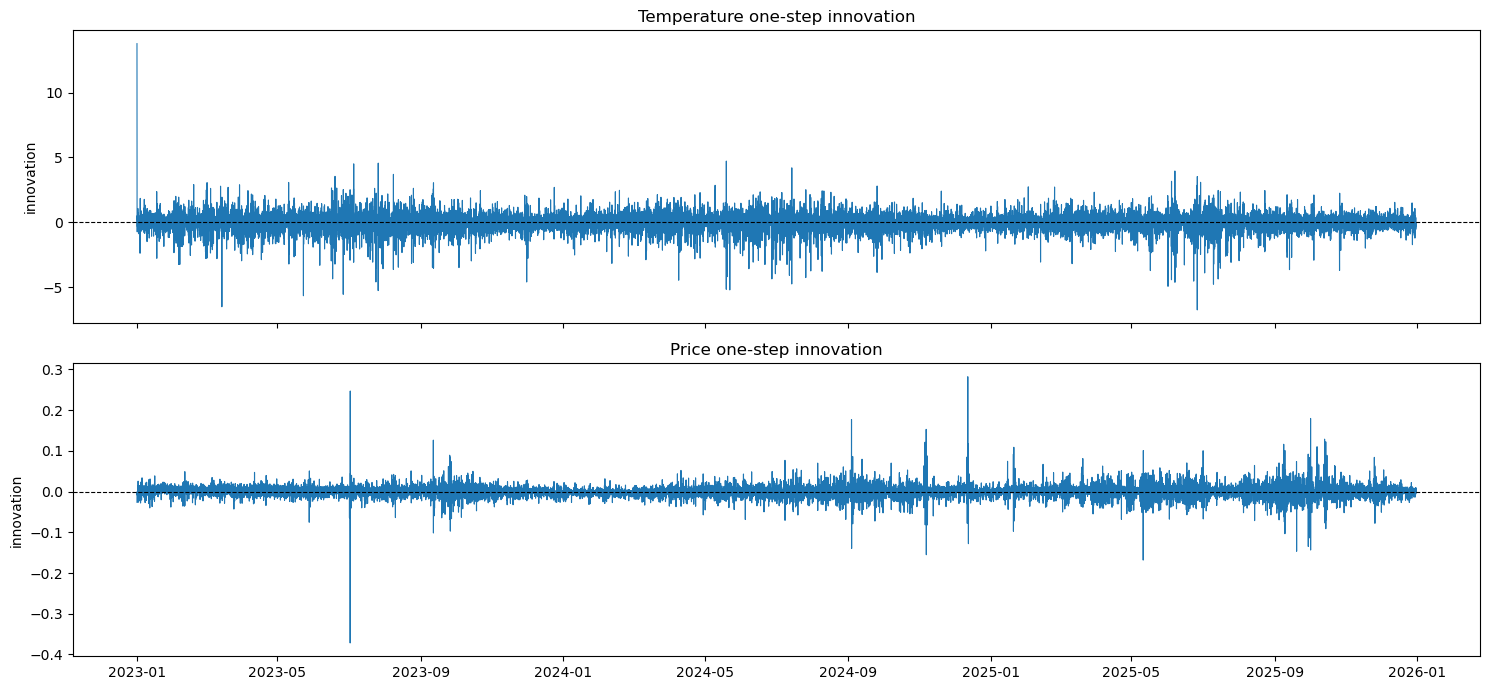

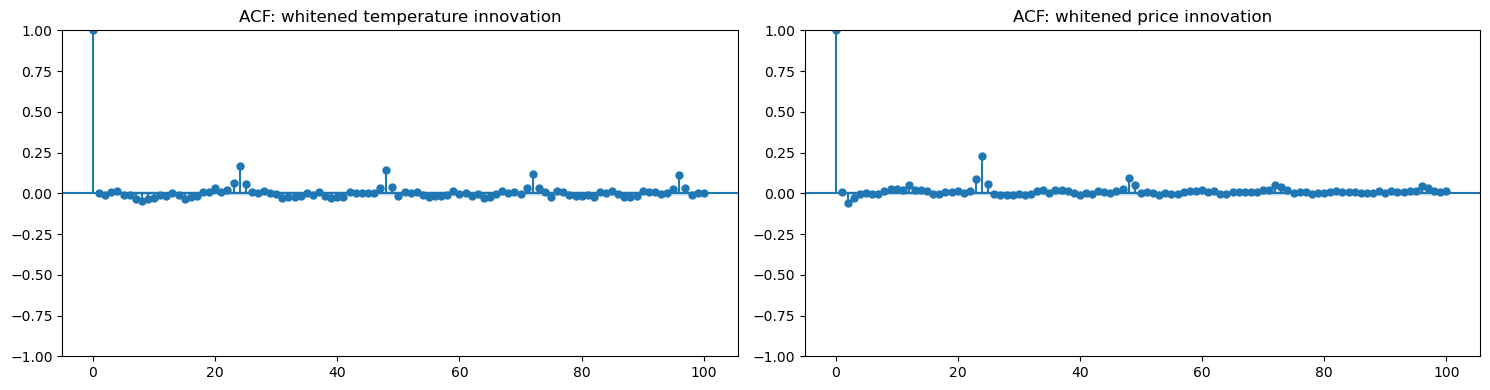

In [105]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(
    mcarma_fit_frame.index,
    mcarma_fit_frame["temp_observed"],
    label="temperature residual",
    linewidth=1.0,
)
axes[0].plot(
    mcarma_fit_frame.index,
    mcarma_fit_frame["temp_predicted"],
    label="MCARMA one-step prediction",
    linewidth=1.0,
)
axes[0].set_title("MCARMA(2,1): temperature one-step-ahead fit")
axes[0].set_ylabel("temperature residual")
axes[0].legend()

axes[1].plot(
    mcarma_fit_frame.index,
    mcarma_fit_frame["price_observed"],
    label="price/log-price residual",
    linewidth=1.0,
)
axes[1].plot(
    mcarma_fit_frame.index,
    mcarma_fit_frame["price_predicted"],
    label="MCARMA one-step prediction",
    linewidth=1.0,
)
axes[1].set_title("MCARMA(2,1): price one-step-ahead fit")
axes[1].set_ylabel("price/log-price residual")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(mcarma_fit_frame.index, mcarma_fit_frame["temp_innovation"], linewidth=0.8)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Temperature one-step innovation")
axes[0].set_ylabel("innovation")

axes[1].plot(mcarma_fit_frame.index, mcarma_fit_frame["price_innovation"], linewidth=0.8)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Price one-step innovation")
axes[1].set_ylabel("innovation")

plt.tight_layout()
plt.show()

acf_lag_count = min(100, len(mcarma_fit_frame) - 1)
if acf_lag_count > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(
        mcarma_fit_frame["temp_whitened_innovation"],
        lags=acf_lag_count,
        ax=axes[0],
    )
    axes[0].set_title("ACF: whitened temperature innovation")
    plot_acf(
        mcarma_fit_frame["price_whitened_innovation"],
        lags=acf_lag_count,
        ax=axes[1],
    )
    axes[1].set_title("ACF: whitened price innovation")
    plt.tight_layout()
    plt.show()


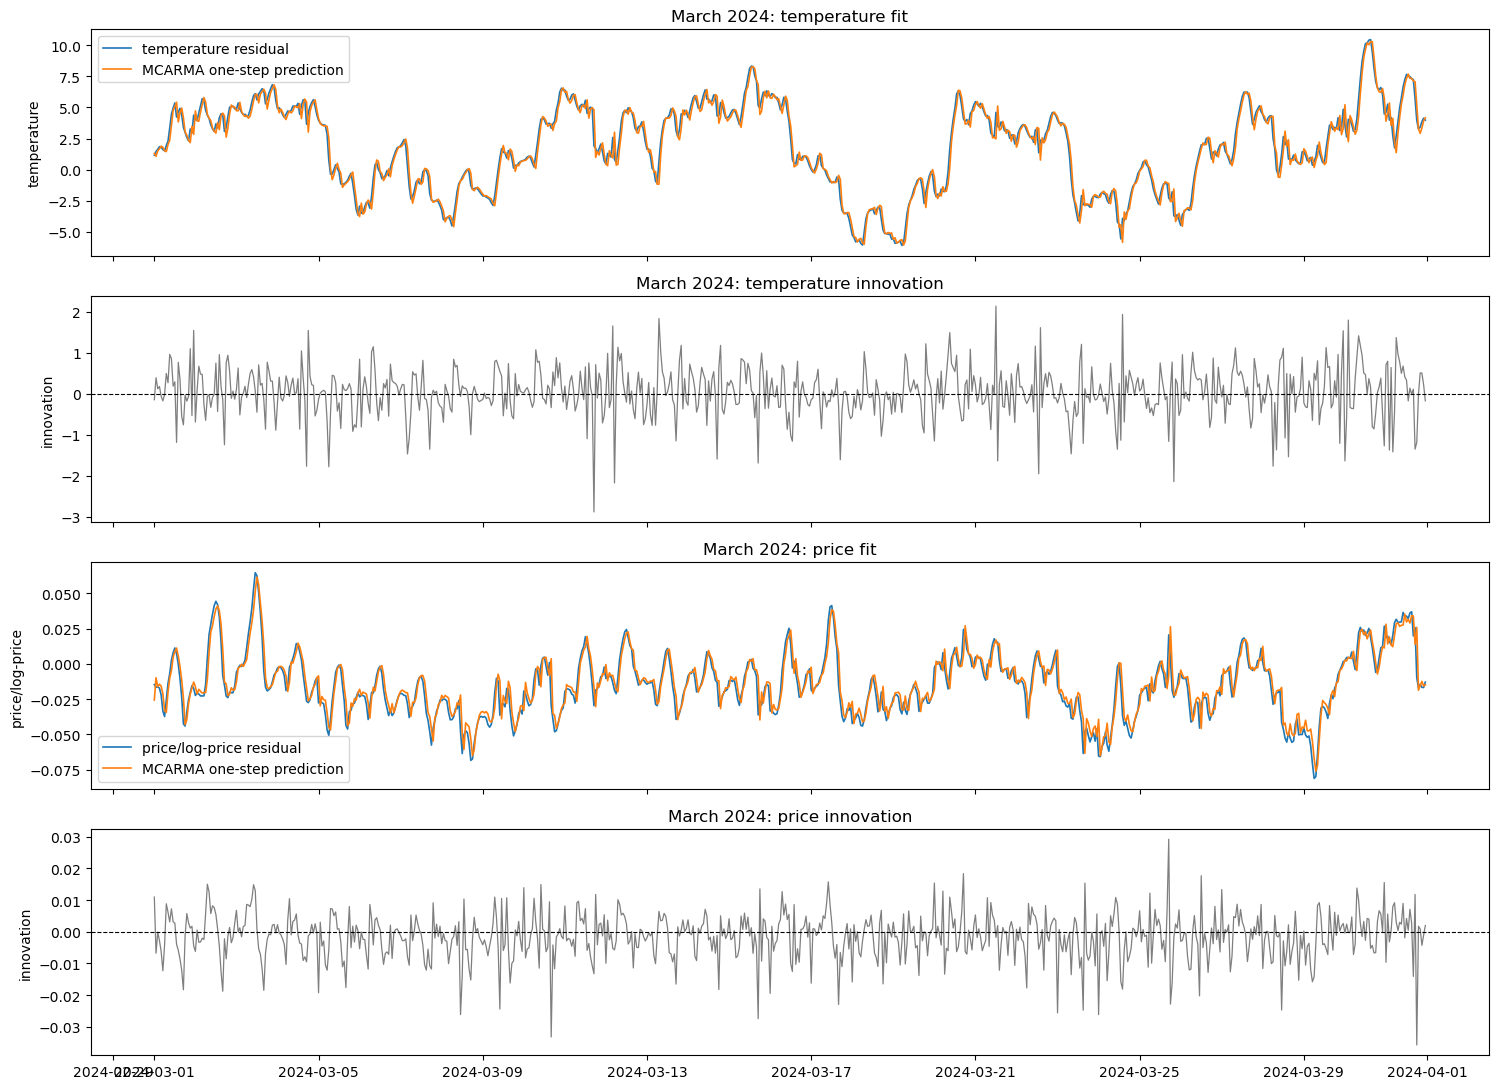

In [106]:
march_2024_mask = (
    (mcarma_fit_frame.index >= pd.Timestamp("2024-03-01", tz="UTC"))
    & (mcarma_fit_frame.index < pd.Timestamp("2024-04-01", tz="UTC"))
)

mcarma_fit_march_2024 = mcarma_fit_frame.loc[march_2024_mask]

if mcarma_fit_march_2024.empty:
    print("No March 2024 observations are available in the aligned MCARMA sample.")
else:
    fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)

    axes[0].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["temp_observed"],
        label="temperature residual",
        linewidth=1.2,
    )
    axes[0].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["temp_predicted"],
        label="MCARMA one-step prediction",
        linewidth=1.2,
    )
    axes[0].set_title("March 2024: temperature fit")
    axes[0].set_ylabel("temperature")
    axes[0].legend()

    axes[1].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["temp_innovation"],
        color="tab:gray",
        linewidth=0.9,
    )
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_title("March 2024: temperature innovation")
    axes[1].set_ylabel("innovation")

    axes[2].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["price_observed"],
        label="price/log-price residual",
        linewidth=1.2,
    )
    axes[2].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["price_predicted"],
        label="MCARMA one-step prediction",
        linewidth=1.2,
    )
    axes[2].set_title("March 2024: price fit")
    axes[2].set_ylabel("price/log-price")
    axes[2].legend()

    axes[3].plot(
        mcarma_fit_march_2024.index,
        mcarma_fit_march_2024["price_innovation"],
        color="tab:gray",
        linewidth=0.9,
    )
    axes[3].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_title("March 2024: price innovation")
    axes[3].set_ylabel("innovation")

    plt.tight_layout()
    plt.show()
